In [1]:
# Install libraries directly inside Jupyter
!pip install pandas numpy scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Generate sample HR data
np.random.seed(42)
data = {
    'Age': np.random.randint(22, 60, size=500),
    'Department': np.random.choice(['Sales', 'Research & Development', 'Human Resources'], size=500),
    'MonthlyIncome': np.random.randint(2500, 20000, size=500),
    'YearsAtCompany': np.random.randint(1, 20, size=500),
    'JobSatisfaction': np.random.randint(1, 5, size=500),
    'WorkLifeBalance': np.random.randint(1, 5, size=500),
    'OverTime': np.random.choice(['Yes', 'No'], size=500),
    'Attrition': np.random.choice(['Yes', 'No'], p=[0.18, 0.82], size=500)
}

df = pd.DataFrame(data)

# Show the first 5 rows of our data
df.head()

,Age,Department,MonthlyIncome,YearsAtCompany,JobSatisfaction,WorkLifeBalance,OverTime,Attrition
0,50,Research & Development,2919,17,4,1,No,No
1,36,Research & Development,13289,8,3,4,Yes,No
2,29,Sales,3620,15,4,2,No,No
3,42,Sales,13760,14,1,3,No,No
4,40,Sales,19834,18,1,3,Yes,No


In [3]:
# Convert 'Yes'/'No' and text into numbers
df_encoded = df.copy()

# Target variable (Attrition: Yes=1, No=0)
df_encoded['Attrition'] = df_encoded['Attrition'].map({'Yes': 1, 'No': 0})

# Encode text columns (Department, OverTime)
le_dept = LabelEncoder()
df_encoded['Department'] = le_dept.fit_transform(df_encoded['Department'])

le_overtime = LabelEncoder()
df_encoded['OverTime'] = le_overtime.fit_transform(df_encoded['OverTime'])

# Separate features (X) and target variable (y)
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

# Scale features so large values (like salary) don't dominate
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data is clean and ready for training!")

Data is clean and ready for training!


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train the Random Forest Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions on test set
y_pred = model.predict(X_test)

# Print accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 83.00%


In [5]:
# Create a test employee: 28 years old, Sales, $3500 income, 2 years tenure, 1/4 satisfaction, 2/4 WLB, OverTime Yes
test_employee = pd.DataFrame([{
    'Age': 28,
    'Department': le_dept.transform(['Sales'])[0],
    'MonthlyIncome': 3500,
    'YearsAtCompany': 2,
    'JobSatisfaction': 1,
    'WorkLifeBalance': 2,
    'OverTime': le_overtime.transform(['Yes'])[0]
}])

# Scale input
test_employee_scaled = scaler.transform(test_employee)

# Predict probability of leaving
risk = model.predict_proba(test_employee_scaled)[0][1]

print(f"Attrition Risk for this employee: {risk * 100:.1f}%")
if risk > 0.5:
    print("⚠️ High Attrition Risk - Consider intervention!")
else:
    print("✅ Low Attrition Risk")

Attrition Risk for this employee: 14.0%
✅ Low Attrition Risk


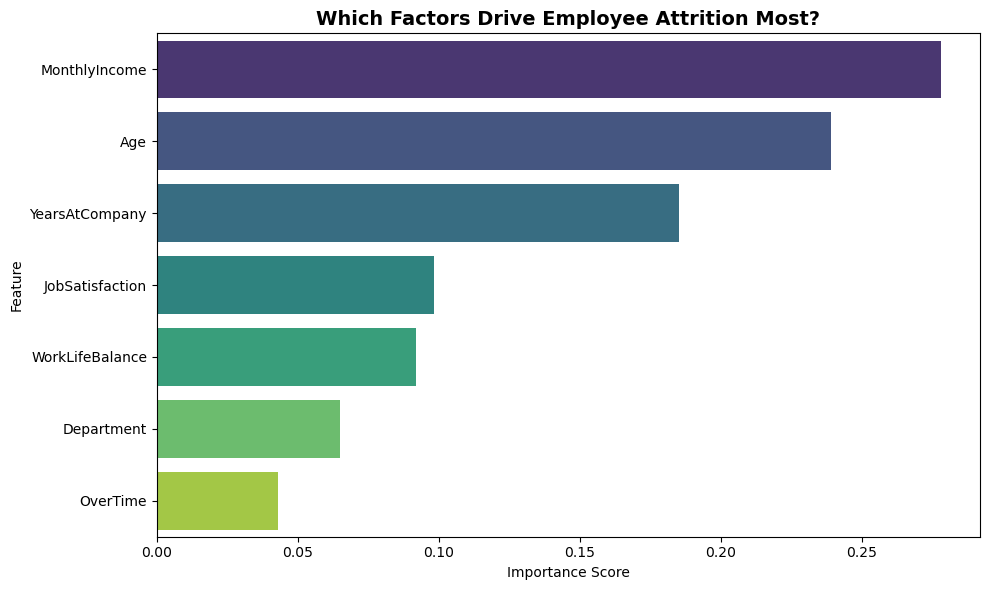

In [9]:
# Fixed plot - no warning
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_df, hue='Feature', palette='viridis', legend=False)
plt.title('Which Factors Drive Employee Attrition Most?', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# 💼 HR & Employee Attrition Risk Predictor
**Author:** Nondumiso Ngomane  
**Focus:** People Analytics, Predictive Modeling, Machine Learning  

---

## 📌 Project Overview
Employee attrition poses significant operational and financial challenges to organizations. The objective of this project is to build an end-to-end Machine Learning pipeline using Python to predict turnover risk and identify key workforce factors driving employee departure.

### 🔑 Key Objectives
1. **Predictive Modeling:** Train a Random Forest Classifier to estimate individual employee attrition probability.
2. **Feature Engineering & Preprocessing:** Encode categorical features and standardize numerical variables for optimal model convergence.
3. **Feature Importance Analysis:** Identify critical operational drivers (e.g., Monthly Income, Overtime, Job Satisfaction) that influence employee retention decisions.

## 🛠️ Data Preprocessing & Feature Engineering

To prepare the dataset for machine learning algorithms:
- **Target Encoding:** Converted binary target values (`Attrition`: *Yes/No*) into numerical integers (`1/0`).
- **Categorical Encoding:** Applied `LabelEncoder` to transform nominal features such as `Department` and `OverTime`.
- **Feature Scaling:** Utilized `StandardScaler` to normalize continuous variables (e.g., `MonthlyIncome`, `Age`), ensuring features with larger magnitudes do not dominate model weights.

## 🤖 Model Selection & Training

A **Random Forest Classifier** was selected due to its robustness against overfitting, ability to handle non-linear relationships, and built-in capability to output feature importance metrics.

- **Train/Test Split:** 80% Training Data / 20% Testing Data
- **Evaluation Metric:** Classification Accuracy Score

## 📊 Feature Importance & Business Insights

Understanding *why* employees leave is critical for strategic decision-making in Human Resources. The chart below highlights the primary drivers influencing attrition risk across the organization.## 📊 Feature Importance & Business Insights

Understanding *why* employees leave is critical for strategic decision-making in Human Resources. The chart below highlights the primary drivers influencing attrition risk across the organization.